In [26]:
austria_path = "_data/AT_2021"
sweden_path = "_data/SE_2021"
portugal_path = "_data/PT_2021"
france_path = "_data/FR_2018"
netherlands_path = "_data/NL_2020"
spain_path = "_data/ES_2020"

In [27]:
# read shapefiles

import geopandas as gpd
austria = gpd.read_file(austria_path)
sweden = gpd.read_file(sweden_path)
portugal = gpd.read_file(portugal_path)

In [29]:
france = gpd.read_file(france_path)
netherlands = gpd.read_file(netherlands_path)
spain = gpd.read_file(spain_path)

In [53]:
# count the most occurent classes
# print(f"Austria most common classes: {austria["EC_hcat_n"].value_counts()[:12]} \n")
# print(f"Sweden most common classes: {sweden["EC_hcat_n"].value_counts()[:12]}")
# print(f"Portugal most common classes: {portugal["EC_hcat_n"].value_counts()[:12]}")

In [30]:
# check if it has data information
print(f"Austria columns has date information: {True if 'GEOM_DATE_' in austria.columns else False} \n")
print(f"Sweden columns has date information: {True if 'GEOM_DATE_' in sweden.columns else False} \n")
print(f"Portugal columns has date information: {True if 'GEOM_DATE_' in portugal.columns else False} \n")
print(f"France columns has date information: {True if 'GEOM_DATE_' in france.columns else False} \n")
print(f"Netherlands columns has date information: {True if 'GEOM_DATE_' in netherlands.columns else False} \n")
print(f"Spain columns has date information: {True if 'GEOM_DATE_' in spain.columns else False}")

Austria columns has date information: True 

Sweden columns has date information: False 

Portugal columns has date information: False 

France columns has date information: False 

Netherlands columns has date information: False 

Spain columns has date information: False


In [31]:
# isolate one crop

# crop = "winter_rye"
crop = "potatoes"

def isolate_crop(gdf, crop):
    cols_to_keep = [
        'fid', 'GEOM_DATE_', 'ID', 
        'EC_hcat_n', 'EC_hcat_c', 'geometry'
    ]
    existing_cols = [c for c in cols_to_keep if c in gdf.columns]
    gdf_filtered = gdf[existing_cols]
    return gdf_filtered[gdf_filtered["EC_hcat_n"] == crop]

austria_crop = isolate_crop(austria, crop)
sweden_crop = isolate_crop(sweden, crop)
portugal_crop = isolate_crop(portugal, crop)
france_crop = isolate_crop(france, crop)
netherlands_crop = isolate_crop(netherlands, crop)
spain_crop = isolate_crop(spain, crop)

print(f"Austria dataset {austria.size} vs {crop} austria dataset {austria_crop.size}")
print(f"Sweden dataset {sweden.size} vs {crop} sweden dataset {sweden_crop.size}")
print(f"Portugal dataset {portugal.size} vs {crop} portugal dataset {portugal_crop.size}")
print(f"France dataset {france.size} vs {crop} france dataset {france_crop.size}")
print(f"Netherlands dataset {netherlands.size} vs {crop} netherlands dataset {netherlands_crop.size}")
print(f"Spain dataset {spain.size} vs {crop} spain dataset {spain_crop.size}")

Austria dataset 49599690 vs potatoes austria dataset 116615
Sweden dataset 23031420 vs potatoes sweden dataset 24976
Portugal dataset 1900000 vs potatoes portugal dataset 1581
France dataset 95178780 vs potatoes france dataset 145227
Netherlands dataset 7670340 vs potatoes netherlands dataset 103677
Spain dataset 25913654 vs potatoes spain dataset 0


In [95]:
# sweden_winter_rye.explore()
# austria_winter_rye.explore()
# portugal_winter_rye.explore()

In [32]:
portugal_crop.head(3)

,EC_hcat_n,EC_hcat_c,geometry
24,potatoes,3301030000,"POLYGON ((-8.51101 40.57921, -8.51101 40.57921..."
55,potatoes,3301030000,"POLYGON ((-8.5077 40.58488, -8.50766 40.58489,..."
373,potatoes,3301030000,"POLYGON ((-9.0454 39.56236, -9.0454 39.56236, ..."


In [103]:
# isolate by year

import pandas as pd

def isolate_year(gdf, target_year):
    gdf['GEOM_DATE_'] = pd.to_datetime(gdf['GEOM_DATE_'])
    gdf['year'] = gdf['GEOM_DATE_'].dt.year
    result = gdf[(gdf["GEOM_DATE_"].dt.year == target_year)]
    return result

for i in range(2018, 2022):
    f"austria{i}" = isolate_year(austria_crop, i)
    print(f"Austria {crop} dataset for year {i} has size: {isolate_year(austria_crop, i).size}")


SyntaxError: cannot assign to f-string expression here. Maybe you meant '==' instead of '='? (3876433659.py, line 12)

In [81]:
austria_winter_rye

,fid,GEOM_DATE_,EC_hcat_n,EC_hcat_c,geometry,year
53,54.0,2021-05-12 08:36:25,winter_rye,3301010301,"POLYGON ((507523.36 509000.271, 507531.955 508...",2021
109,110.0,2021-03-11 15:49:26,winter_rye,3301010301,"POLYGON ((515409.601 501380.733, 515400.703 50...",2021
242,243.0,2018-07-31 15:33:11,winter_rye,3301010301,"POLYGON ((548474.911 508901.488, 548475.991 50...",2018
286,287.0,2019-09-10 13:24:09,winter_rye,3301010301,"POLYGON ((560868.086 505134.479, 560887.99 505...",2019
448,449.0,2018-07-31 15:32:44,winter_rye,3301010301,"POLYGON ((527418.203 480776.801, 527411.311 48...",2018
...,...,...,...,...,...,...
2609260,2609261.0,2018-07-31 16:20:40,winter_rye,3301010301,"POLYGON ((670233.018 461639.221, 670231.346 46...",2018
2609669,2609670.0,2018-07-31 16:20:40,winter_rye,3301010301,"POLYGON ((670549.274 461222.63, 670574.324 461...",2018
2610192,2610193.0,2019-04-23 19:54:09,winter_rye,3301010301,"POLYGON ((613881.838 397159.686, 613867.363 39...",2019
2610345,2610346.0,2020-10-07 17:53:19,winter_rye,3301010301,"POLYGON ((614038.205 397205.848, 614043.494 39...",2020


In [82]:
austria_rye_2021

,fid,GEOM_DATE_,EC_hcat_n,EC_hcat_c,geometry,year
242,243.0,2018-07-31 15:33:11,winter_rye,3301010301,"POLYGON ((548474.911 508901.488, 548475.991 50...",2018
448,449.0,2018-07-31 15:32:44,winter_rye,3301010301,"POLYGON ((527418.203 480776.801, 527411.311 48...",2018
563,564.0,2018-07-31 16:15:22,winter_rye,3301010301,"POLYGON ((618170.383 517139.676, 618241.937 51...",2018
719,720.0,2018-07-31 13:44:39,winter_rye,3301010301,"POLYGON ((448506.566 486093.216, 448528.065 48...",2018
852,853.0,2018-07-31 16:15:15,winter_rye,3301010301,"POLYGON ((621929.034 512551.479, 621927.648 51...",2018
...,...,...,...,...,...,...
2608102,2608103.0,2018-07-31 13:49:12,winter_rye,3301010301,"POLYGON ((488099.82 509693.074, 488094.466 509...",2018
2608695,2608696.0,2018-07-31 16:20:40,winter_rye,3301010301,"POLYGON ((669890.989 461682.494, 669890.092 46...",2018
2608976,2608977.0,2018-07-31 14:41:34,winter_rye,3301010301,"POLYGON ((546635.374 563783.417, 546643.361 56...",2018
2609260,2609261.0,2018-07-31 16:20:40,winter_rye,3301010301,"POLYGON ((670233.018 461639.221, 670231.346 46...",2018


In [1]:
tinycrops_path = "_data/tinyEuroCrops"

In [5]:
import datetime as dt
import numpy as np
import os
import h5py
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

In [6]:
# Specify dataset path to where you downloaded https://www.eurocrops.tum.de/downloads.html
dataset_dir = '_data'

# Get all paths
train_h5_dir  = os.path.join(dataset_dir, 'tinyEuroCrops/HDF5s/train/')
train_csv_dir = os.path.join(dataset_dir, 'tinyEuroCrops/csv_labels/train/')
test_h5_dir   = os.path.join(dataset_dir, 'tinyEuroCrops/HDF5s/test/')
test_csv_dir  = os.path.join(dataset_dir, 'tinyEuroCrops/csv_labels/test/')

# check they all exist
print(os.path.exists(test_csv_dir))
print(os.path.exists(test_h5_dir))
print(os.path.exists(train_csv_dir))
print(os.path.exists(train_h5_dir))

True
True
True
True


In [21]:
selected_file = os.path.join(test_h5_dir, 'AT_T33UWP_test.h5')

In [22]:
# METHOD 2 - load the full HDF5
# load same file as above but with h5py rather than pd.HDFStore
h5_file = h5py.File(selected_file, 'r')
regions =  list(h5_file.keys())
print('Available regions: ' + str(regions))

Available regions: ['AT121']


In [23]:
# select the name of the first item from the regions list
study_region = regions[0]
df_data2 = pd.read_hdf(selected_file, key=study_region)
print(study_region)

AT121


- **Rows**: parcel ID
- **Cols**: timesteps
- **Cells**: 13 representative reflectances (median value) for a parcel, each corresponding to one band of the SENTIEL-2 Satellites.

AT train2020

In [24]:
df_data2.head(2)

,20190106,20190111,20190116,20190121,20190205,20190215,20190220,20190225,20190307,20190312,...,20190918,20190923,20191008,20191013,20191018,20191023,20191107,20191122,20191207,20191227
146,"[5907, 5339, 4457, 4537, 4568, 4587, 4628, 433...","[3750, 3795, 3157, 3217, 3366, 3521, 3681, 347...","[2291, 1902, 1538, 1426, 1609, 1834, 1965, 183...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[2275, 2125, 1579, 1367, 1651, 1692, 1787, 134...","[1328, 980, 698, 569, 717, 816, 938, 794, 449,...","[1533, 1156, 796, 621, 687, 774, 817, 752, 333...","[4161, 4131, 3699, 3774, 3883, 4003, 4055, 423...","[1270, 1024, 819, 807, 980, 1171, 1301, 1263, ...","[6056, 6131, 5696, 6155, 6436, 6683, 6832, 678...",...,"[1110, 833, 748, 448, 849, 1894, 2077, 2283, 9...","[7763, 8199, 8016, 8704, 8516, 8929, 9568, 899...","[2150, 1805, 1564, 1427, 1581, 2061, 2280, 219...","[3056, 3435, 3300, 3552, 3502, 3925, 4357, 415...","[1253, 908, 661, 457, 625, 989, 1060, 875, 364...","[3302, 3288, 2990, 3022, 3258, 3504, 3692, 357...","[1357, 986, 660, 454, 578, 717, 796, 634, 334,...","[3708, 3284, 2822, 2965, 3050, 3292, 3473, 322...","[5078, 5153, 4742, 5376, 5722, 6048, 6291, 581...","[6038, 5835, 4938, 5309, 5463, 5519, 5533, 562..."
151,"[5392, 4825, 3928, 3879, 3937, 3904, 3929, 376...","[3856, 2650, 1868, 1564, 1605, 1869, 1867, 153...","[5418, 5218, 4758, 5027, 4982, 5318, 5466, 536...","[3229, 2336, 1704, 1347, 1266, 1538, 1505, 130...","[3267, 2301, 1676, 1377, 1238, 1436, 1385, 130...","[3073, 1964, 1434, 1173, 1156, 1330, 1346, 106...","[2347, 1552, 1253, 1128, 1281, 1502, 1538, 146...","[1861, 1497, 1185, 1043, 1051, 1221, 1326, 125...","[1895, 1484, 1281, 1250, 1440, 1826, 2024, 188...","[5999, 5851, 5404, 5861, 6158, 6371, 6495, 655...",...,"[1117, 754, 561, 360, 611, 1247, 1523, 1215, 1...","[2997, 2994, 2679, 2588, 2614, 3138, 3493, 328...","[2195, 1865, 1641, 1497, 1692, 2337, 2616, 247...","[1273, 842, 597, 382, 512, 969, 1156, 903, 598...","[1209, 892, 629, 407, 484, 979, 1116, 1194, 46...","[1331, 934, 658, 401, 509, 1003, 1118, 845, 74...","[1317, 918, 605, 381, 446, 734, 825, 732, 508,...","[1592, 1170, 800, 594, 656, 878, 958, 856, 589...","[1707, 1244, 813, 549, 604, 906, 961, 895, 474...","[6334, 6027, 5198, 5824, 6015, 6092, 6106, 591..."


In [27]:
# select corresponding csv file to the selected .h5 file
csv_file_path = os.path.join(train_csv_dir, 'demo_eurocrops_' + study_region + '.csv')
print(csv_file_path)
print("Exists:", os.path.exists(csv_file_path))

df_labels = pd.read_csv(csv_file_path, index_col=0)

_data/tinyEuroCrops/csv_labels/train/demo_eurocrops_AT112.csv
Exists: True


In [28]:
df_labels.head(5)

,crpgrpc,crpgrpn
recno,,
463,33111022,leguminous_plants
464,33111022,leguminous_plants
504,33111022,leguminous_plants
577,33111022,leguminous_plants
578,33111022,leguminous_plants


In [29]:
# Let's select a parcel from the HDF5 data and then find the correstponding attribute data

# Pick the first row from the HDF data
example_row = df_data2.iloc[0]
recno = example_row.name

# Get the corresponding attribute data (from the CSV file)
crop_code = df_labels.loc[recno]['crpgrpc']
crop_type = df_labels.loc[recno]['crpgrpn']

print('Crop {} (of class {}) grows on rec_no {}'.format(crop_type, crop_code, recno))

Crop leguminous_plants (of class 33111022) grows on rec_no 463


In [31]:
# Let's peek at the data from the HDF data for the selected example
df_data2.loc[recno]

20190106    [3871, 3600, 2992, 3105, 3205, 3320, 3321, 348...
20190111    [1638, 1193, 780, 647, 692, 732, 763, 680, 545...
20190113    [1679, 1241, 845, 742, 805, 866, 945, 854, 399...
20190116    [2379, 2016, 1670, 1642, 1736, 1883, 1962, 191...
20190118    [6992, 6542, 5944, 6414, 6786, 6859, 6973, 674...
                                  ...                        
20191129    [2450, 2039, 1665, 1577, 1608, 1668, 1691, 160...
20191204    [1695, 1244, 889, 708, 763, 913, 966, 912, 343...
20191207    [1552, 1127, 692, 473, 442, 437, 421, 370, 159...
20191224    [1770, 1294, 898, 732, 802, 954, 1015, 953, 36...
20191227    [1608, 1196, 756, 582, 571, 603, 590, 563, 320...
Name: 463, Length: 80, dtype: object

In [32]:
# The columns of the dataframe correspond to the timesteps
timesteps = list(df_data2.columns)

# Get the current year by taking the first timestep (all are from the same year)
year = int(timesteps[0][:4])
first_day_of_year = dt.datetime(year=year, month=1, day=1)

# Subtract start of the year from each time stamp to get the day of the year of each measure
tf = '%Y%m%d'
days_of_year = [((dt.datetime.strptime(date, tf) - first_day_of_year).days + 1) for date in timesteps]

# should be a list of values between 1-365
print(days_of_year)

[6, 11, 13, 16, 18, 36, 38, 43, 46, 48, 51, 56, 58, 66, 71, 73, 78, 81, 83, 88, 91, 96, 106, 108, 111, 118, 121, 128, 138, 146, 151, 153, 156, 158, 163, 166, 168, 171, 176, 178, 181, 183, 186, 196, 198, 201, 206, 213, 216, 221, 223, 226, 228, 231, 241, 243, 246, 248, 251, 253, 256, 258, 261, 263, 266, 273, 281, 283, 286, 288, 291, 296, 298, 311, 326, 333, 338, 341, 358, 361]


In [33]:
# convert from list (one dimensional) of 80 lists of 7 reflectance values
# to a (two dimensional) array of 80 rows by 13 reflectance columns
np_er = example_row.to_numpy()
np_er_stack = np.stack(example_row, axis=0)

# get the dimension 1D, 2D, 3D
#np_er_stack.ndim 
# 80, 17
#np_er_stack.shape 

# check the first row
np_er_stack[0]

array([3871, 3600, 2992, 3105, 3205, 3320, 3321, 3482, 2042,  107, 2859,
       2289, 3352])

Text(0, 0.5, 'Reflectance value')

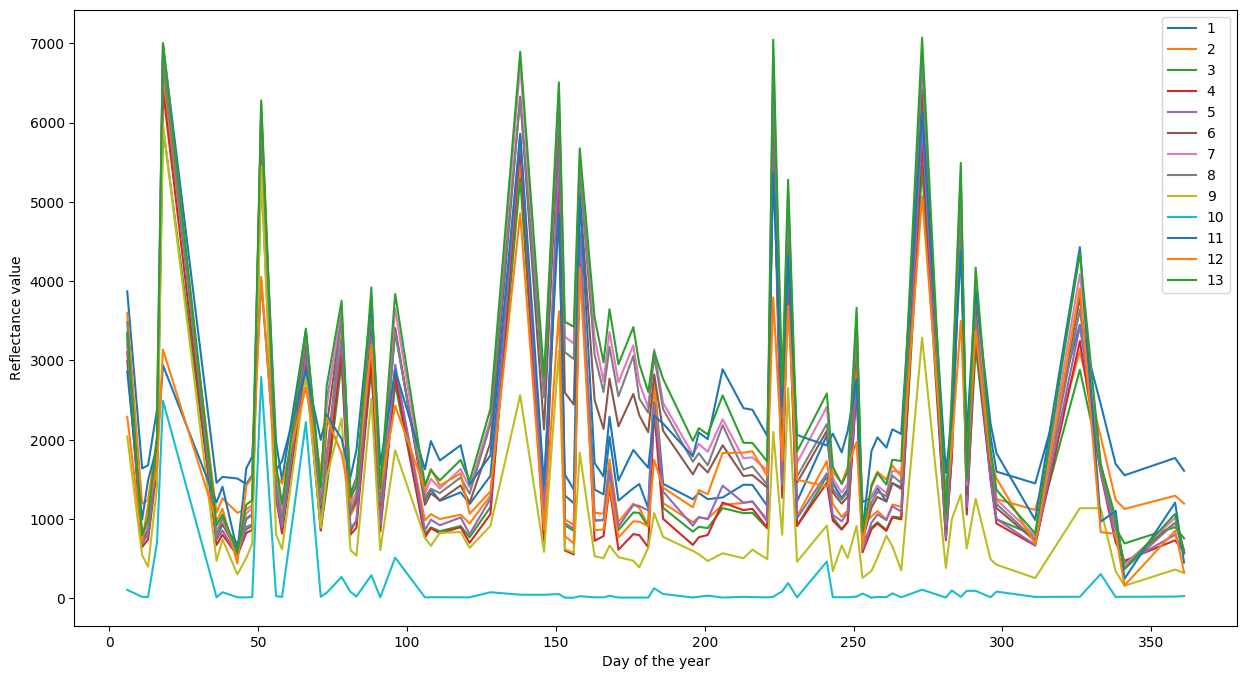

In [34]:
plt.rcParams['figure.figsize'] = [15, 8] # dimension of figure

# reflectance bands are not equally-spaced but we do so here for simplicity
# for more information see: https://gisgeography.com/sentinel-2-bands-combinations/
plt.plot(days_of_year, np_er_stack)
plt.legend(range(1,np_er_stack.shape[1]+1))
plt.style.use('_classic_test_patch')
plt.xlabel('Day of the year')
plt.ylabel('Reflectance value')

Crop fruit_of_temperate_climate_zones (of class 33301010) grows on rec_no 968745


Text(0, 0.5, 'Reflectance value')

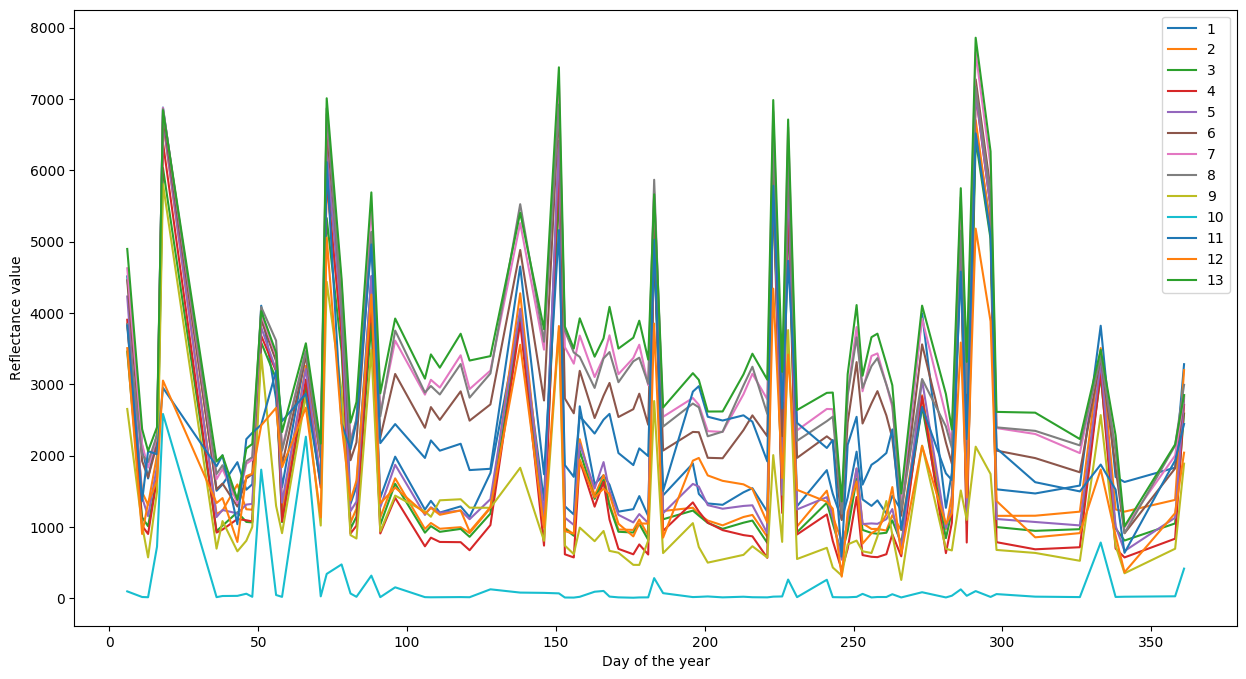

In [36]:
# Pick the last row
example_row2 = df_data2.iloc[-1]
recno2 = example_row2.name

# Get the corresponding label (from the CSV file)
crop_code2 = df_labels.loc[recno2]['crpgrpc']
crop_type2 = df_labels.loc[recno2]['crpgrpn']

print('Crop {} (of class {}) grows on rec_no {}'.format(crop_type2, crop_code2, recno2))

# convert from list to 2d-matrix
np_er2 = example_row2.to_numpy()
np_er_stack2 = np.stack(example_row2, axis=0)

# do the graphing
plt.rcParams['figure.figsize'] = [15, 8]
plt.plot(days_of_year, np_er_stack2)
plt.legend(range(1,np_er_stack.shape[1]+1))
plt.style.use('_classic_test_patch')
plt.xlabel('Day of the year')
plt.ylabel('Reflectance value')